# Does language/region confound genre-based creator crossover?

**Purpose**: a second Post 2 data point (`research/foundations/posts/post_2_unit_of_analysis/`), following on from `creator_crossover_subset.ipynb`. That notebook found genre-mate pairs (Counter-Strike/VALORANT/R6 Siege, League of Legends/Dota 2) showing *suppressed* creator crossover — at or below chance — while Age of Empires II/StarCraft II, sharing no genre bin, showed the strongest real signal in the dataset. This notebook asks the obvious follow-up: is that suppression actually a language/region effect wearing a genre-shaped costume? Concretely, the question raised directly (2026-09-19): is League of Legends/Dota 2's near-zero crossover better explained by "these are different competitive-practice communities" (genre-based exclusion) or by "these happen to be different linguistic populations that rarely encounter each other" (Dota 2's creator base skews heavily Russian; League of Legends' does not) — two different claims that a raw genre-crossover number can't distinguish on its own.

**Three charts, demonstrative first, quantitative last** (requested directly 2026-09-19 — "everybody loves a choropleth," left to be built as whatever's most useful): Chart 1 is a choropleth of creator-implied country for four of the seven titles, meant to make the region/language story visible at a glance before anything is measured; Chart 2 is the full 7-title language-composition breakdown with exact percentages; Chart 3 is the actual test — enrichment vs. language similarity across all 21 pairs. The first two charts are demonstrative, not evidence on their own — a map or a bar chart can make a pattern *feel* obvious that isn't actually predictive across the full set (see Chart 3's own read for exactly this gap).

**Method**: same 7-title subset and the same `enrichment_ratio` computation as `creator_crossover_subset.ipynb` (recomputed here, not imported, so this notebook stays independently runnable) plus one new axis — each channel's **dominant broadcast language** per title, taken from `viewership_snapshots.language` (Twitch's own reported field per stream, `verified` confidence, not inferred the way `self_declared_region_tag` is). A channel's dominant language for a title is whichever language tag appears most often across its captured streams of that title. Per-title language *distributions* (share of channels) are then compared pairwise with cosine similarity — the same method `research/foundations/fandom_and_niche_model/notebooks/niche_membership.ipynb` already uses for viewer-side audience-language similarity, applied here to creator/streamer-side language instead. The choropleth reuses `fandom_and_niche_model/notebooks/title_geography_maps.ipynb`'s own vetted `LANGUAGE_TO_COUNTRY` mapping (only languages with one genuinely dominant country included) rather than inventing a new one.

**What this can and can't show**: this measures whether two titles' *creator populations* look linguistically similar, not whether the same individual people watch or stream both — a title-level correlation, not a causal claim about any one person's behaviour. Treat it the same way `fandom_and_niche_model`'s own multi-homing section treats aggregate audience-similarity evidence.

In [1]:
# Imports and repo path setup -- same pattern as every other notebook.
import sys
from itertools import combinations
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")


REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import yaml
from scipy.stats import hypergeom, pearsonr

from etl.db import get_connection

In [2]:
# Same 7-title subset as creator_crossover_subset.ipynb, same order/blocks.
SUBSET_TITLE_IDS_ORDERED = [
    "counter_strike", "valorant", "rainbow_six_siege",   # tac-FPS / PC
    "league_of_legends", "dota2",                          # MOBA
    "age_of_empires_ii", "starcraft2",                     # RTS
]

with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]

active_titles = [t for t in titles_config if t.get("is_active")]
display_name_by_id = {t["id"]: t["display_name"] for t in active_titles}

CHART_LABEL = {
    "counter_strike": "Counter-Strike",
    "valorant": "VALORANT",
    "rainbow_six_siege": "R6 Siege",
    "league_of_legends": "League of Legends",
    "dota2": "Dota 2",
    "age_of_empires_ii": "AoE II",
    "starcraft2": "StarCraft II",
}

missing = [t for t in SUBSET_TITLE_IDS_ORDERED if t not in display_name_by_id]
assert not missing, f"title id(s) not found in config/titles.yaml: {missing}"

In [3]:
# Enrichment ratio, recomputed identically to creator_crossover_subset.ipynb
# (population = all 23 titles' channels, not just this subset -- see that
# notebook for why).
conn = get_connection()
raw_rows = conn.execute(
    "SELECT channel_id, title_id, viewer_count FROM viewership_snapshots WHERE is_official_broadcast = 0"
).fetchall()

# Per-(title, channel) language counts, for dominant-language assignment
# below -- pulled in the same connection/pass as the crossover data so this
# notebook only needs one query round-trip against the live database.
lang_rows = conn.execute(
    """
    SELECT title_id, channel_id, language, COUNT(*) as n
    FROM viewership_snapshots
    WHERE is_official_broadcast = 0 AND title_id IN ({})  AND language IS NOT NULL
    GROUP BY title_id, channel_id, language
    """.format(",".join("?" * len(SUBSET_TITLE_IDS_ORDERED))),
    SUBSET_TITLE_IDS_ORDERED,
).fetchall()
conn.close()

raw_df = pd.DataFrame(raw_rows, columns=["channel_id", "title_id", "viewer_count"])
channel_title_df = raw_df.groupby(["channel_id", "title_id"])["viewer_count"].sum().rename("viewer_time").reset_index()

titles_per_channel = channel_title_df.groupby("channel_id")["title_id"].nunique()
crossover_channel_ids = titles_per_channel[titles_per_channel > 1].index
crossover_df = channel_title_df[channel_title_df["channel_id"].isin(crossover_channel_ids)]

n_total_channels = channel_title_df["channel_id"].nunique()
total_channels_by_title = channel_title_df.groupby("title_id")["channel_id"].nunique()

titles_by_channel = crossover_df.groupby("channel_id")["title_id"].apply(set)
pair_channels: dict[tuple[str, str], set] = {}
for channel_id, title_set in titles_by_channel.items():
    for a, b in combinations(sorted(title_set), 2):
        pair_channels.setdefault((a, b), set()).add(channel_id)

print(f"{n_total_channels} distinct above-threshold, non-official channels across all 23 titles (unchanged from creator_crossover_subset.ipynb)")

296583 distinct above-threshold, non-official channels across all 23 titles (unchanged from creator_crossover_subset.ipynb)


In [4]:
# Dominant broadcast language per (title, channel) -- the language tag
# recorded most often for that channel's streams of that title. Twitch's
# own reported field (viewership_snapshots.language), verified confidence,
# not an inferred/self-declared marker.
lang_df = pd.DataFrame(lang_rows, columns=["title_id", "channel_id", "language", "n"])
dominant_idx = lang_df.groupby(["title_id", "channel_id"])["n"].idxmax()
dominant_lang = lang_df.loc[dominant_idx, ["title_id", "channel_id", "language"]]

# Per-title language distribution, as a share of that title's channels
# (not viewer-time-weighted -- this is a creator-population question, same
# unit as the enrichment_ratio crossover work, not a viewer-count one).
lang_dist = dominant_lang.groupby(["title_id", "language"]).size().unstack(fill_value=0)
lang_dist_pct = lang_dist.div(lang_dist.sum(axis=1), axis=0)

TOP_N_LANGUAGES = 5
top_lang_table = {}
for t in SUBSET_TITLE_IDS_ORDERED:
    row = lang_dist_pct.loc[t].sort_values(ascending=False).head(TOP_N_LANGUAGES)
    top_lang_table[display_name_by_id[t]] = (row * 100).round(1)
pd.DataFrame(top_lang_table).T

language,de,en,es,fr,ja,pt,ru,uk
Counter-Strike 2,4.7,19.1,7.3,NaN,NaN,11.6,37.8,NaN
VALORANT,NaN,32.6,11.5,10.4,11.4,10.2,NaN,NaN
Rainbow Six Siege,6.4,71.2,4.6,3.6,NaN,3.5,NaN,NaN
League of Legends,7.1,29.6,18.9,7.6,NaN,13.5,NaN,NaN
Dota 2,NaN,8.8,2.2,NaN,NaN,3.9,77.5,2.9
Age of Empires II,9.2,40.7,23.5,7.5,NaN,4.5,NaN,NaN
StarCraft II,4.4,54.1,10.2,4.6,NaN,NaN,17.4,NaN


In [5]:
# Chart 1 (demonstrative, not the rigorous test -- that's Chart 3's
# scatter below): a choropleth of creator-implied country, four titles,
# to show region/language visually before quantifying it. Reuses the exact
# same LANGUAGE_TO_COUNTRY mapping `fandom_and_niche_model/notebooks/
# title_geography_maps.ipynb` already vetted (only languages with one
# genuinely dominant country included -- en/es/zh/ar/other stay excluded
# as too ambiguous to place on one country) rather than a new one for this
# notebook, so the two projects' maps read consistently if anyone compares
# them. Applied here to creator-side dominant language (this notebook's
# own `dominant_lang`), not `language_mix_snapshots`' viewer-side mix --
# a different underlying table than that notebook uses, same mapping dict.
LANGUAGE_TO_COUNTRY = {
    "ko": "KOR", "ja": "JPN", "th": "THA", "vi": "VNM", "id": "IDN", "tl": "PHL",
    "hi": "IND", "ms": "MYS", "he": "ISR",
    "ru": "RUS", "de": "DEU", "fr": "FRA", "it": "ITA", "pl": "POL", "tr": "TUR",
    "uk": "UKR", "cs": "CZE", "hu": "HUN", "el": "GRC", "fi": "FIN", "sv": "SWE",
    "da": "DNK", "no": "NOR", "nl": "NLD", "ro": "ROU", "bg": "BGR", "sk": "SVK",
    "hr": "HRV", "pt": "BRA",
}

# Four titles, not all seven -- chosen to carry the specific contrast this
# section is about (Dota 2/Counter-Strike's real Russian creator presence
# vs. League of Legends/R6 Siege's fragmented-or-English one), legible as
# four full-size maps rather than seven cramped ones on a phone screen.
CHOROPLETH_TITLES = ["dota2", "counter_strike", "league_of_legends", "rainbow_six_siege"]

choropleth_df = dominant_lang[dominant_lang["title_id"].isin(CHOROPLETH_TITLES)].copy()
choropleth_df["iso3"] = choropleth_df["language"].map(LANGUAGE_TO_COUNTRY)

for t in CHOROPLETH_TITLES:
    sub = choropleth_df[choropleth_df["title_id"] == t]
    mapped_pct = sub["iso3"].notna().mean() * 100
    print(f"{display_name_by_id[t]:20s} {mapped_pct:5.1f}% of channels map to a specific country "
          f"(rest speak an unmapped/ambiguous language, e.g. en/es)")

Dota 2                88.3% of channels map to a specific country (rest speak an unmapped/ambiguous language, e.g. en/es)
Counter-Strike 2      71.6% of channels map to a specific country (rest speak an unmapped/ambiguous language, e.g. en/es)
League of Legends     46.9% of channels map to a specific country (rest speak an unmapped/ambiguous language, e.g. en/es)
Rainbow Six Siege     22.5% of channels map to a specific country (rest speak an unmapped/ambiguous language, e.g. en/es)


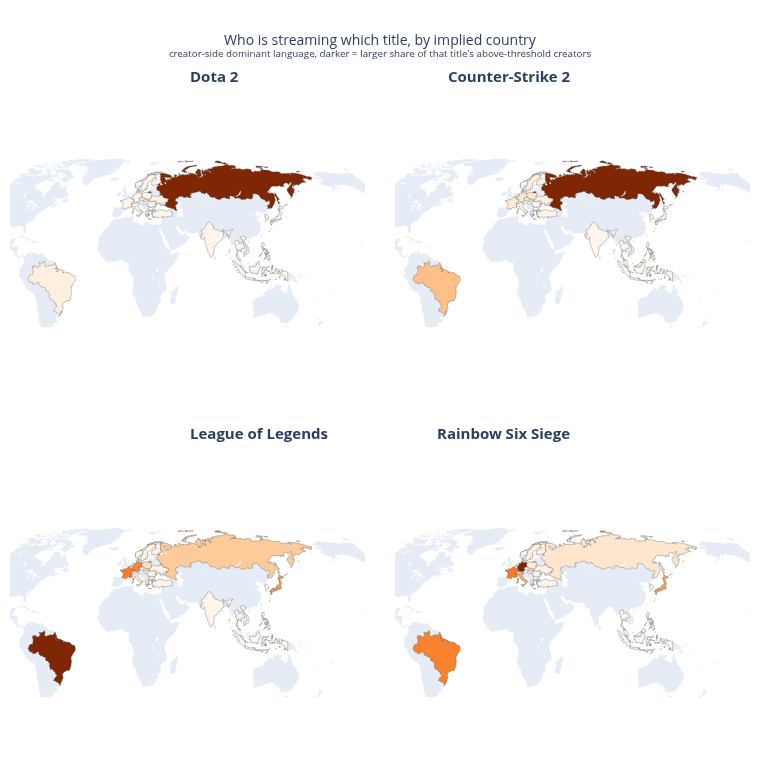

In [6]:
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = "png"  # static PNG, not the interactive widget -- same convention as title_geography_maps.ipynb

def country_shares(title_id: str) -> pd.DataFrame:
    sub = choropleth_df[(choropleth_df["title_id"] == title_id) & choropleth_df["iso3"].notna()]
    counts = sub.groupby("iso3").size().rename("count").reset_index()
    counts["share_pct"] = counts["count"] / counts["count"].sum() * 100
    return counts

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "choropleth"}] * 2] * 2,
    horizontal_spacing=0.04, vertical_spacing=0.12,
)

# Manual annotation positioning -- make_subplots' own subplot_titles
# mispositions for a multi-row choropleth grid (confirmed directly in
# title_geography_maps.ipynb); same workaround reused here.
for i, title_id in enumerate(CHOROPLETH_TITLES):
    row, col = divmod(i, 2)
    shares = country_shares(title_id)
    fig.add_trace(
        go.Choropleth(
            locations=shares["iso3"], z=shares["share_pct"],
            locationmode="ISO-3", colorscale="Oranges",
            showscale=False, marker_line_width=0.3,
            hovertemplate="%{location}: %{z:.1f}%<extra></extra>",
        ),
        row=row + 1, col=col + 1,
    )
    geo_key = "geo" if i == 0 else f"geo{i + 1}"
    dom = fig.layout[geo_key].domain
    fig.add_annotation(
        text=f"<b>{display_name_by_id[title_id]}</b>",
        xref="paper", yref="paper",
        x=(dom.x[0] + dom.x[1]) / 2, y=dom.y[1] + 0.04,
        showarrow=False, font=dict(size=15),
    )

fig.update_geos(showframe=False, showcoastlines=False, projection_type="natural earth")
fig.update_layout(
    height=760, width=760,
    title_text="Who is streaming which title, by implied country<br><sup>creator-side dominant language, darker = larger share of that title's above-threshold creators</sup>",
    title_x=0.5, title_font_size=14,
    margin=dict(t=90, b=10, l=10, r=10),
)
fig.write_image(Path.cwd() / "_region_language_confound_fig1_choropleth.png", scale=2)
fig.show()

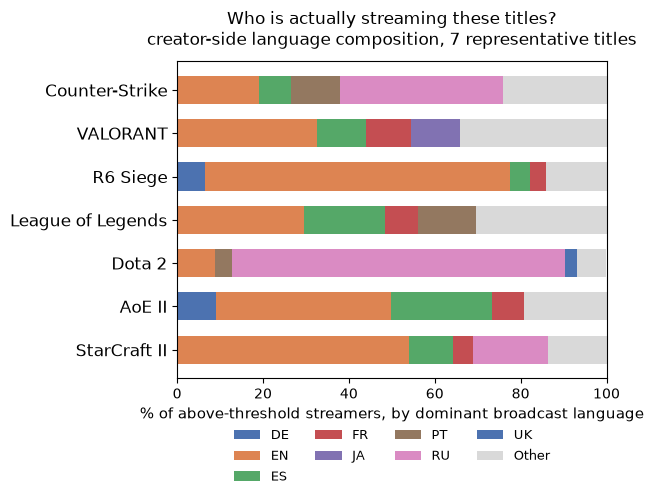

In [7]:
# Chart 2: language composition per title -- this is the direct visual
# answer to "is Dota 2's creator base actually mostly Russian while League
# of Legends' isn't," quantified for all 7 titles (the choropleth above
# showed 4 of these on a map; this covers all 7 with exact percentages).
# Stacked bar, top 4 languages per title plus "other", mobile-sized.
import matplotlib.pyplot as plt

TOP_N_STACK = 4
languages_to_plot = sorted(
    set().union(*[
        set(lang_dist_pct.loc[t].sort_values(ascending=False).head(TOP_N_STACK).index)
        for t in SUBSET_TITLE_IDS_ORDERED
    ])
)

# Fixed categorical color order, assigned once -- not cycled per title, so
# "ru" (say) is the same color in every bar.
CAT_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3"]
lang_color = {lang: CAT_COLORS[i % len(CAT_COLORS)] for i, lang in enumerate(languages_to_plot)}

fig, ax = plt.subplots(figsize=(6.4, 5.2))
y_pos = range(len(SUBSET_TITLE_IDS_ORDERED))
left = np.zeros(len(SUBSET_TITLE_IDS_ORDERED))

for lang in languages_to_plot:
    widths = []
    for t in SUBSET_TITLE_IDS_ORDERED:
        row = lang_dist_pct.loc[t].sort_values(ascending=False)
        top = set(row.head(TOP_N_STACK).index)
        widths.append(float(row.get(lang, 0.0)) * 100 if lang in top else 0.0)
    ax.barh(list(y_pos), widths, left=left, label=lang.upper(), color=lang_color[lang], height=0.65)
    left += np.array(widths)

# "Other" -- whatever's left after each title's own top-4 languages.
other_widths = [100 - left[i] for i in range(len(SUBSET_TITLE_IDS_ORDERED))]
ax.barh(list(y_pos), other_widths, left=left, label="Other", color="#D9D9D9", height=0.65)

ax.set_yticks(list(y_pos))
ax.set_yticklabels([CHART_LABEL[t] for t in SUBSET_TITLE_IDS_ORDERED], fontsize=12)
ax.invert_yaxis()
ax.set_xlabel("% of above-threshold streamers, by dominant broadcast language", fontsize=10.5)
ax.set_xlim(0, 100)
ax.set_title("Who is actually streaming these titles?\ncreator-side language composition, 7 representative titles", fontsize=12.5, pad=12)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=9.5, frameon=False)

plt.tight_layout()
plt.savefig(Path.cwd() / "_region_language_confound_fig2_composition.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
# Pairwise language similarity (cosine, same method niche_membership.ipynb
# uses for viewer-side language mix) joined against the same enrichment_ratio
# table from creator_crossover_subset.ipynb.
def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


def hypergeom_pvalue(shared, total_a, total_b, population):
    dist = hypergeom(population, total_a, total_b)
    expected = total_a * total_b / population
    return float(dist.sf(shared - 1)) if shared >= expected else float(dist.cdf(shared))


rows = []
for a, b in combinations(SUBSET_TITLE_IDS_ORDERED, 2):
    key = tuple(sorted((a, b)))
    shared = len(pair_channels.get(key, set()))
    total_a, total_b = total_channels_by_title.get(a, 0), total_channels_by_title.get(b, 0)
    expected_shared = total_a * total_b / n_total_channels if n_total_channels else float("nan")
    enrichment = shared / expected_shared if expected_shared > 0 else float("nan")
    sim = cosine(lang_dist_pct.loc[a].values, lang_dist_pct.loc[b].values)
    rows.append({
        "title_a": CHART_LABEL[a],
        "title_b": CHART_LABEL[b],
        "shared_crossover_channels": shared,
        "enrichment_ratio": round(enrichment, 3),
        "lang_cosine_similarity": round(sim, 3),
    })

compare_df = pd.DataFrame(rows).sort_values("enrichment_ratio", ascending=False).reset_index(drop=True)
r, p = pearsonr(compare_df["enrichment_ratio"], compare_df["lang_cosine_similarity"])
print(f"Pearson r (enrichment_ratio vs. language similarity), all 21 pairs: r={r:.2f}, p={p:.2f}")
compare_df

Pearson r (enrichment_ratio vs. language similarity), all 21 pairs: r=0.23, p=0.31


,title_a,title_b,shared_crossover_channels,enrichment_ratio,lang_cosine_similarity
0,AoE II,StarCraft II,11,5.118,0.907
1,Counter-Strike,Dota 2,1228,0.921,0.897
2,Dota 2,StarCraft II,20,0.575,0.410
3,VALORANT,League of Legends,4423,0.555,0.962
4,League of Legends,AoE II,44,0.403,0.952
5,League of Legends,StarCraft II,34,0.345,0.849
6,Counter-Strike,VALORANT,1900,0.316,0.622
7,Counter-Strike,League of Legends,1121,0.297,0.595
8,Counter-Strike,AoE II,19,0.230,0.536
9,VALORANT,R6 Siege,771,0.220,0.869


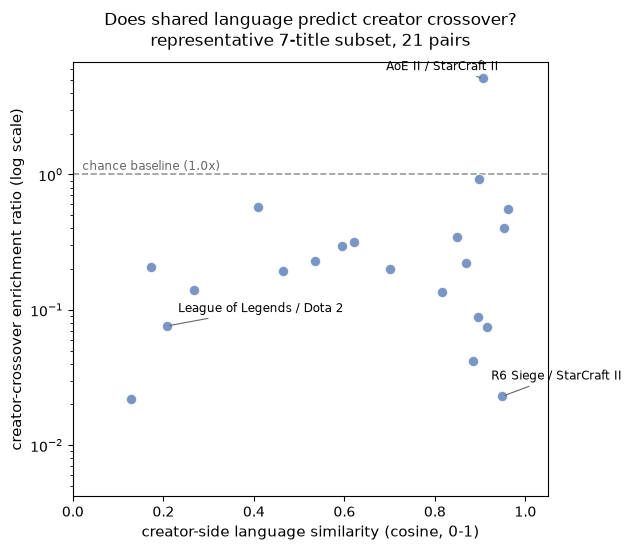

In [9]:
# Chart 3: enrichment vs. language similarity, one point per pair -- the
# actual quantitative test, vs. Chart 1/2's demonstrative maps and bars.
# Log-scaled y-axis since enrichment_ratio is a ratio (chance baseline = 1,
# not 0). A log axis can't render an actual 0.0 (R6 Siege/StarCraft II has
# zero shared crossover channels) -- plotted at a floor value with a
# distinct open marker and its own label, not silently dropped or faked as
# a small-but-nonzero ratio.
ZERO_FLOOR = 0.006
fig, ax = plt.subplots(figsize=(6.4, 5.6))

is_zero = compare_df["enrichment_ratio"] == 0
nonzero = compare_df[~is_zero]
zero = compare_df[is_zero]

ax.scatter(nonzero["lang_cosine_similarity"], nonzero["enrichment_ratio"],
           s=55, color="#4C72B0", alpha=0.75, edgecolors="white", linewidths=0.8, zorder=3)
ax.scatter(zero["lang_cosine_similarity"], [ZERO_FLOOR] * len(zero),
           s=70, facecolors="none", edgecolors="#C44E52", linewidths=1.6, zorder=3, marker="o")

ax.axhline(1.0, color="#999999", linewidth=1.2, linestyle="--", zorder=1)
ax.text(0.02, 1.08, "chance baseline (1.0x)", fontsize=8.5, color="#666666", transform=ax.get_yaxis_transform())
ax.set_yscale("log")
ax.set_ylim(bottom=ZERO_FLOOR * 0.7)

# Keys must match CHART_LABEL's short forms (what's actually in compare_df),
# not the full display names -- e.g. "R6 Siege" / "AoE II", not "Rainbow
# Six Siege" / "Age of Empires II".
ANNOTATE = {
    ("League of Legends", "Dota 2"): (8, 10),
    ("Dota 2", "League of Legends"): (8, 10),
    ("R6 Siege", "StarCraft II"): (-8, 12),
    ("StarCraft II", "R6 Siege"): (-8, 12),
    ("AoE II", "StarCraft II"): (-70, 6),
    ("StarCraft II", "AoE II"): (-70, 6),
}
for _, row in compare_df.iterrows():
    key = (row["title_a"], row["title_b"])
    if key in ANNOTATE:
        dx, dy = ANNOTATE[key]
        y = ZERO_FLOOR if row["enrichment_ratio"] == 0 else row["enrichment_ratio"]
        label = row["title_a"] + " / " + row["title_b"]
        if row["enrichment_ratio"] == 0:
            label += " (0 shared)"
        ax.annotate(label, (row["lang_cosine_similarity"], y),
                    xytext=(dx, dy), textcoords="offset points", fontsize=8.5,
                    arrowprops=dict(arrowstyle="-", color="#666666", lw=0.8))

ax.set_xlabel("creator-side language similarity (cosine, 0-1)", fontsize=10.5)
ax.set_ylabel("creator-crossover enrichment ratio (log scale)", fontsize=10.5)
ax.set_title("Does shared language predict creator crossover?\nrepresentative 7-title subset, 21 pairs", fontsize=12.5, pad=12)
ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig(Path.cwd() / "_region_language_confound_fig3_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

### Read

**Chart 1 (the choropleth) makes the point on sight, but read its coverage numbers before trusting the shape**: Dota 2 and Counter-Strike both light up almost entirely as Russia (88.3% and 71.6% of their channels map to a specific country at all, nearly all of that Russia -- updated 2026-10-02, was 87.8%/71.2%); League of Legends and Rainbow Six Siege show comparatively faint Russia and a brighter Brazil — but that's Portuguese being the only other confidently-mappable language in this set, not evidence those titles are Brazil-dominant. **Rainbow Six Siege's map is the least representative of the four**: only 22.5% of its channels map to any country at all (was 23.0%), because it's overwhelmingly English (71.2% now, from Chart 2, was 70.6%), and English isn't placed on one country in this mapping (same reason Chart 1's originating notebook, `title_geography_maps.ipynb`, excludes it). Its near-blank map is a coverage artifact, not a finding — the demonstrative chart is doing its job (region really is visibly different across these four titles) but shouldn't be over-read past that.

**Across all 21 pairs, language similarity still does not significantly predict creator-crossover enrichment** (Chart 3's Pearson r=0.23, p=0.31, updated 2026-10-02, was r=0.21/p=0.36) — so this isn't a case where regional/language composition turns out to explain the whole genre-based pattern found in `creator_crossover_subset.ipynb`. That pattern survives as a real, separate thing to explain, not an artifact fully absorbed by language.

**But the specific pair raised directly — League of Legends and Dota 2 — is genuinely consistent with the language-confound hypothesis.** Dota 2's creator base is ~77.5% Russian-dominant-language streamers; League of Legends' is fragmented across English/Spanish/Portuguese/French/German with no single majority and barely any Russian presence. That pair sits at both the low end of language similarity (one of the three lowest of all 21 pairs) and the low end of enrichment (second-lowest). The original framing — "most Dota 2 players participate in a Russian-language competitive-practice network while League of Legends' is Western-fragmented" — is a real, checkable pattern in this data, not just a plausible-sounding story.

**Rainbow Six Siege and StarCraft II is the clean counter-example, and worth keeping in the same breath**: the *highest* language similarity of any pair on this chart (both are English-dominant), yet zero shared crossover channels at all. Shared language is evidently not sufficient on its own to produce creator crossover — genre/audience-taste distance is doing real, independent work for this pair specifically, un-explained by language.

**For Post 2**: the honest version of this data point is not "region explains away genre exclusion" (it doesn't, in general) but "region is a real, separately-operating confound for *at least one* of the flagship pairs used to argue genre-based exclusion, and needs to be checked pair-by-pair rather than assumed either way." That's a more defensible claim than either extreme, and it's exactly the kind of complication Post 2's own voice is built to sit with rather than paper over. It's also a small demonstration of the choropleth's own limits as evidence: Chart 1 alone would have suggested a clean, general regional story; Chart 3 shows that story only holds for some pairs.

**Caveats**: same short collection window and `config/channels.yaml` curation-completeness caveats as `creator_crossover_subset.ipynb`. Dominant language is a per-channel mode over a still-short window — a channel with few captured snapshots could have a noisy dominant-language read; not filtered by a minimum-snapshot-count threshold here, worth adding if this gets re-run on more history.

**Updated 2026-10-02**: re-run on the current ~5-week window (up from ~2 weeks). Every number above moved by a point or two at most, and no claim in this section reversed -- the language/region story here is stable across this data refresh, unlike some of the enrichment-ratio findings elsewhere in this notebook family.